In [ ]:
!pip install kaggle
!kaggle -v
!kaggle datasets download -d yelp-dataset/yelp-dataset -p yelp_data
!unzip yelp_data/yelp-dataset.zip -d yelp_data

Kaggle API 1.7.4.5
Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
yelp-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  yelp_data/yelp-dataset.zip
replace yelp_data/Dataset_User_Agreement.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: yelp_data/Dataset_User_Agreement.pdf  
replace yelp_data/yelp_academic_dataset_business.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace yelp_data/yelp_academic_dataset_checkin.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace yelp_data/yelp_academic_dataset_review.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace yelp_data/yelp_academic_dataset_tip.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace yelp_data/yelp_academic_dataset_user.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
#import EVERYTHING !!

!pip install -q prophet
!pip install -q wordcloud
!pip install -q xgboost
!pip install -q shap
!pip install -q spacy
!pip install -q plotly
!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import json
import os
import re
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

#machine learning imports
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


#time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

#gradient boost
import lightgbm as lgb
import xgboost as xgb

#nlp
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
import spacy
import re
from collections import Counter

#visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

#nltk data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


#data manipulation
from datetime import datetime, timedelta
import calendar


#time series
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import xgboost as xgb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
# load business data
import pandas as pd

business_file = '/content/yelp_data/yelp_academic_dataset_business.json'
review_file   = '/content/yelp_data/yelp_academic_dataset_review.json'
checkin_file  = '/content/yelp_data/yelp_academic_dataset_checkin.json'
tip_file      = '/content/yelp_data/yelp_academic_dataset_tip.json'
user_file     = '/content/yelp_data/yelp_academic_dataset_user.json'

# sample 10,000 businesses in chunks
chunks = pd.read_json(business_file, lines=True, chunksize=100000)
sampled_businesses = []

for chunk in chunks:
    sampled_chunk = chunk.sample(frac=0.1, random_state=42)  #10% from each chunk
    sampled_businesses.append(sampled_chunk)

df_business = pd.concat(sampled_businesses).sample(n=10000, random_state=42)
df_business = df_business[['business_id','name','city','state','stars','review_count','categories','latitude','longitude']]
print("Businesses loaded:", len(df_business))


business_ids = set(df_business['business_id'])


review_chunks = pd.read_json(review_file, lines=True, chunksize=10000)
filtered_reviews = []

for chunk in review_chunks:
    filtered_chunk = chunk[chunk['business_id'].isin(business_ids)]
    filtered_reviews.append(filtered_chunk)

df_reviews = pd.concat(filtered_reviews)
df_reviews = df_reviews[['review_id','user_id','business_id','stars','date','text','useful','funny','cool']]
print("Reviews loaded:", len(df_reviews))


checkin_chunks = pd.read_json(checkin_file, lines=True, chunksize=10000)
filtered_checkins = []

for chunk in checkin_chunks:
    filtered_chunk = chunk[chunk['business_id'].isin(business_ids)]
    filtered_checkins.append(filtered_chunk)

df_checkin = pd.concat(filtered_checkins)
df_checkin = df_checkin[['business_id','date']]
print("Check-ins loaded:", len(df_checkin))


tip_chunks = pd.read_json(tip_file, lines=True, chunksize=10000)
filtered_tips = []

for chunk in tip_chunks:
    filtered_chunk = chunk[chunk['business_id'].isin(business_ids)]
    filtered_tips.append(filtered_chunk)

df_tip = pd.concat(filtered_tips)
df_tip = df_tip[['user_id','business_id','text','date']]
print("Tips loaded:", len(df_tip))


user_ids = pd.concat([df_reviews['user_id'], df_tip['user_id']]).unique()
user_chunks = pd.read_json(user_file, lines=True, chunksize=10000)
filtered_users = []

for chunk in user_chunks:
    filtered_chunk = chunk[chunk['user_id'].isin(user_ids)]
    filtered_users.append(filtered_chunk)

df_user = pd.concat(filtered_users)
df_user = df_user[['user_id','name','review_count','yelping_since','useful','funny','cool','fans','average_stars']]
print("Users loaded:", len(df_user))


Businesses loaded: 10000
Reviews loaded: 468809
Check-ins loaded: 8746
Tips loaded: 61504
Users loaded: 322543


In [ ]:
import pandas as pd



#expand check-in timestamps into individual rows
df_checkin['date'] = df_checkin['date'].astype(str)

df_checkin['date_list'] = df_checkin['date'].str.split(", ")


df_checkins_expanded = df_checkin.explode('date_list')

df_checkins_expanded['date_list'] = pd.to_datetime(df_checkins_expanded['date_list'], errors='coerce')


df_checkins_expanded['date'] = df_checkins_expanded['date_list'].dt.date
df_checkins_expanded['hour'] = df_checkins_expanded['date_list'].dt.hour


df_checkins_expanded = df_checkins_expanded[['business_id','date','hour']]

print("businesses:", len(df_business))
print("reviews:", len(df_reviews))
print("check-ins (expanded):", len(df_checkins_expanded))

businesses: 10000
reviews: 468809
check-ins (expanded): 883096


data analysis


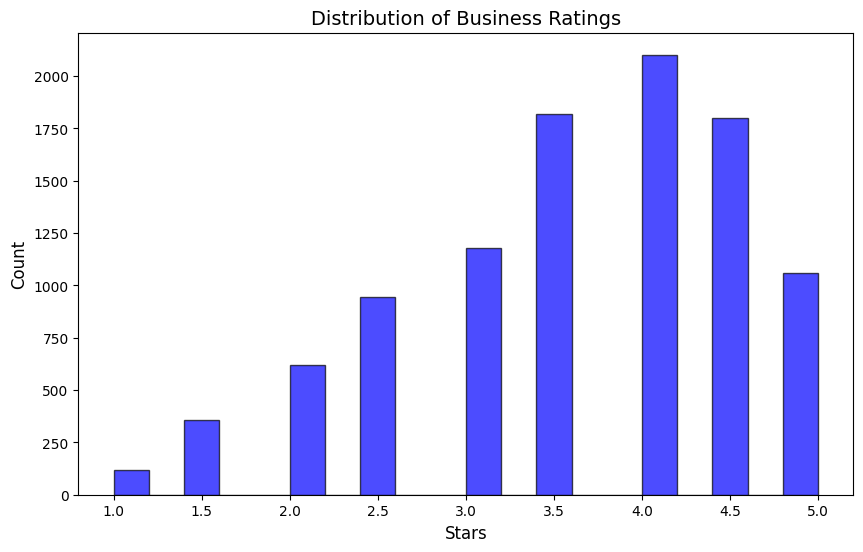

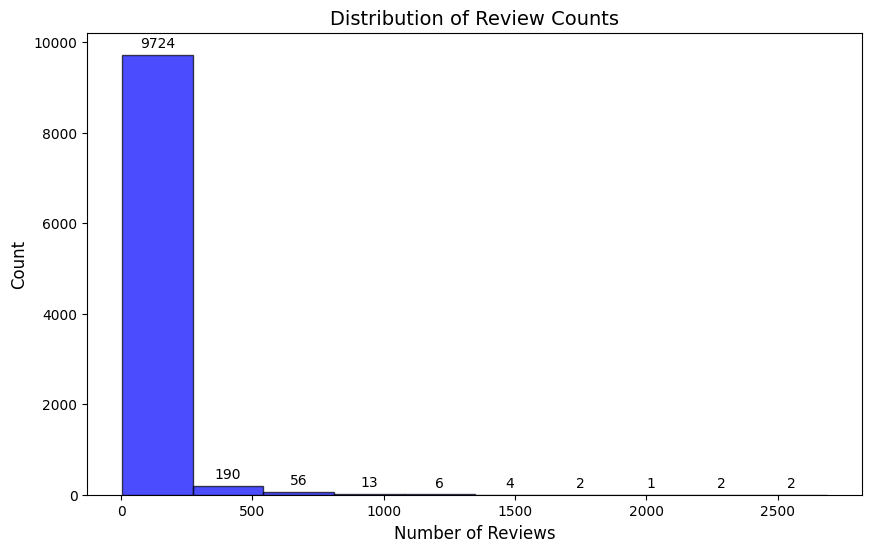

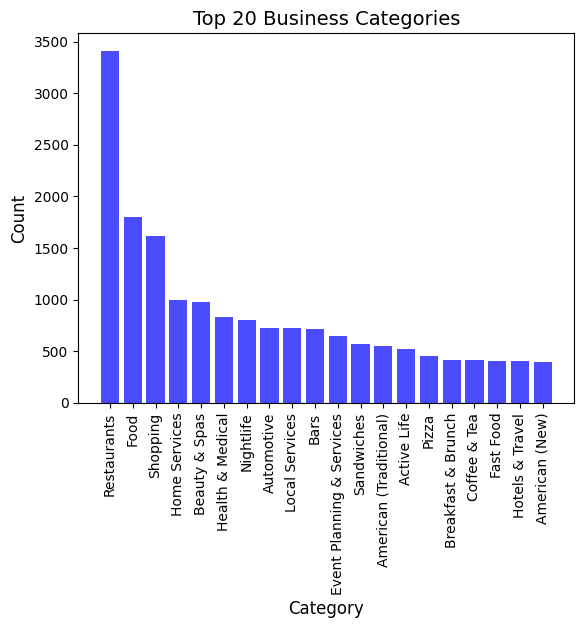

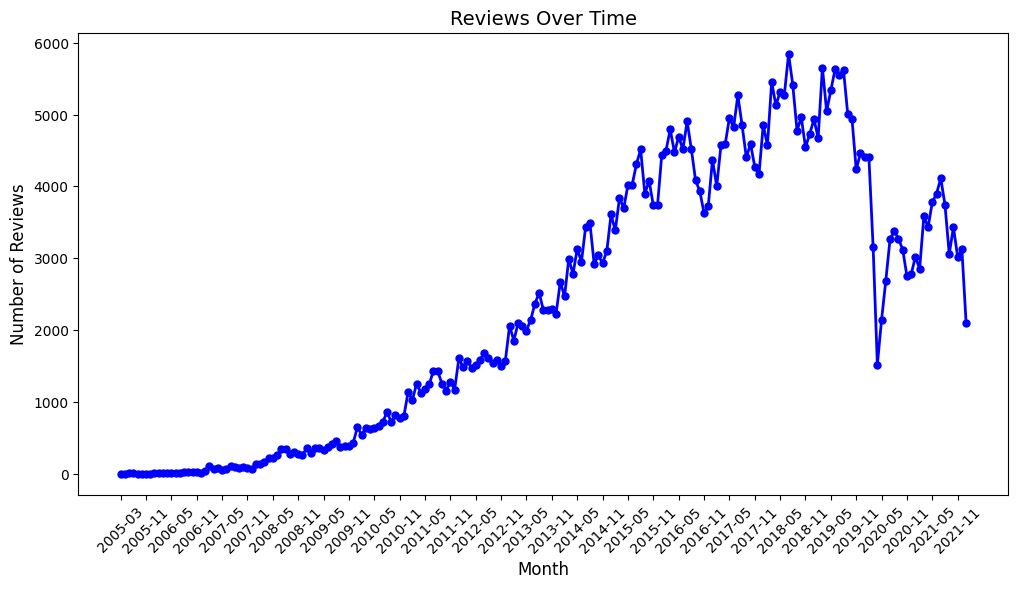

In [ ]:
# data exploration
import matplotlib.pyplot as plt

print("data analysis")
#business distribution
plt.figure(figsize=(10,6))
#rating distribution
plt.hist(df_business['stars'], bins=20, edgecolor='black', color='blue', alpha=0.7)
plt.title('Distribution of Business Ratings', fontsize=14)
plt.xlabel('Stars', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

plt.figure(figsize=(10,6))

#reviews per business
counts, bins, patches = plt.hist(df_business['review_count'], bins=10,
                                 edgecolor='black', color='blue', alpha=0.7)

plt.title('Distribution of Review Counts', fontsize=14)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Count', fontsize=12)

#add counts on top of each bar
for i in range(len(counts)):
    if counts[i] > 0:
        plt.text(bins[i] + (bins[i+1] - bins[i])/2,
                 counts[i] + max(counts)*0.01,
                 str(int(counts[i])),
                 ha='center', va='bottom',
                 fontsize=10)

plt.show()
#category distribution
from collections import Counter
all_categories = df_business['categories'].dropna().str.split(', ')
flat_categories = [cat.strip() for sublist in all_categories for cat in sublist]
category_counts = Counter(flat_categories)
top_categories = dict(category_counts.most_common(20))
plt.bar(top_categories.keys(), top_categories.values(), color='blue', alpha=0.7)
plt.title('Top 20 Business Categories', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90, fontsize=10)  # rotate 90 degrees and reduce font size
plt.show()

plt.figure(figsize=(12,6))
#reviews over time
df_reviews['date'] = pd.to_datetime(df_reviews['date'], errors='coerce')
df_reviews['month'] = df_reviews['date'].dt.to_period('M')
monthly_reviews = df_reviews.groupby('month').size()
monthly_reviews.index = monthly_reviews.index.astype(str)
plt.plot(monthly_reviews.index, monthly_reviews.values, marker='o', color='blue', linewidth=2, markersize=5)
plt.title('Reviews Over Time', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(monthly_reviews.index[::6], rotation=45, fontsize=10)  # show every 6th month to reduce crowding
plt.show()

In [ ]:
#filter for food related businesses only
food_keywords = ['Restaurants', 'Food', 'Cafes']

#check if categories contain food related keywords
def is_food_related(categories):
    if isinstance(categories, str):
        categories_lower = categories.lower()
        for keyword in food_keywords:
            if keyword.lower() in categories_lower:
                return True
    return False

# filter the business dataframe
df_business_food = df_business[df_business['categories'].apply(is_food_related)]
print(f"food related businesses: {len(df_business_food)}")

#get business IDs for filtering other datasets
business_ids_food = set(df_business_food['business_id'])


filtered_reviews_food = df_reviews[df_reviews['business_id'].isin(business_ids_food)]
print(f"food related reviews: {len(filtered_reviews_food)}")


df_checkins_expanded_food = df_checkins_expanded[df_checkins_expanded['business_id'].isin(business_ids_food)]
print(f"food related check-ins (expanded): {len(df_checkins_expanded_food)}")


df_tip_food = df_tip[df_tip['business_id'].isin(business_ids_food)]
print(f"food related tips: {len(df_tip_food)}")

user_ids_food = pd.concat([filtered_reviews_food['user_id'], df_tip_food['user_id']]).unique()

#filter users who have reviews or tips in food businesses
df_user_food = df_user[df_user['user_id'].isin(user_ids_food)]
print(f"users with food related activity: {len(df_user_food)}")



df_business = df_business_food
df_reviews = filtered_reviews_food
df_checkins_expanded = df_checkins_expanded_food
df_tip = df_tip_food
df_user = df_user_food


print(f"food businesses: {len(df_business)}")
print(f"food related reviews: {len(df_reviews)}")
print(f"food related check ins: {len(df_checkins_expanded)}")
print(f"food related tips: {len(df_tip)}")
print(f"users with food activity: {len(df_user)}")

food related businesses: 4222
food related reviews: 340902
food related check-ins (expanded): 664145
food related tips: 48193
users with food related activity: 240702
food businesses: 4222
food related reviews: 340902
food related check ins: 664145
food related tips: 48193
users with food activity: 240702


In [ ]:
# filter more
business_checkin_counts = df_checkins_expanded.groupby('business_id').size().reset_index(name='total_checkins')
print(f"Businesses with check-in data: {len(business_checkin_counts)}")


business_review_counts = df_business[['business_id', 'review_count']].copy()


business_stats = business_review_counts.merge(business_checkin_counts, on='business_id', how='inner')

#filter for businesses with at least 20 reviews AND 20 check-ins
min_reviews = 20
min_checkins = 20

qualified_businesses = business_stats[
    (business_stats['review_count'] >= min_reviews) &
    (business_stats['total_checkins'] >= min_checkins)
]

print(f"businesses with ≥{min_reviews} reviews and ≥{min_checkins} check-ins: {len(qualified_businesses)}")

#list of business IDs
qualified_business_ids = set(qualified_businesses['business_id'])



#filter businesses
df_business = df_business[df_business['business_id'].isin(qualified_business_ids)]
print(f"qualified food businesses: {len(df_business)}")


df_reviews = df_reviews[df_reviews['business_id'].isin(qualified_business_ids)]
print(f"qualified food reviews: {len(df_reviews)}")


df_checkins_expanded = df_checkins_expanded[df_checkins_expanded['business_id'].isin(qualified_business_ids)]
print(f"qualified food check-ins: {len(df_checkins_expanded)}")


df_tip = df_tip[df_tip['business_id'].isin(qualified_business_ids)]
print(f"qualified food tips: {len(df_tip)}")


qualified_user_ids = pd.concat([df_reviews['user_id'], df_tip['user_id']]).unique()
df_user = df_user[df_user['user_id'].isin(qualified_user_ids)]
print(f"users with qualified food activity: {len(df_user)}")

print(f"\ndataset sizes:")
print(f"businesses: {len(df_business)}")
print(f"reviews: {len(df_reviews)}")
print(f"check-ins: {len(df_checkins_expanded)}")
print(f"tips: {len(df_tip)}")
print(f"users: {len(df_user)}")

Businesses with check-in data: 4153
businesses with ≥20 reviews and ≥20 check-ins: 2261
qualified food businesses: 2261
qualified food reviews: 313467
qualified food check-ins: 621033
qualified food tips: 44121
users with qualified food activity: 224910

dataset sizes:
businesses: 2261
reviews: 313467
check-ins: 621033
tips: 44121
users: 224910


In [ ]:
#check if we're using filtered data

print(f"number of businesses in df_business: {len(df_business)}")
print(f"number of reviews in df_reviews: {len(df_reviews)}")
print(f"number of check-ins in df_checkins_expanded: {len(df_checkins_expanded)}")

print("\nsample business categories: food-related:")
print(df_business['categories'].head(5))

number of businesses in df_business: 2261
number of reviews in df_reviews: 313467
number of check-ins in df_checkins_expanded: 621033

sample business categories: food-related:
111594    Fast Food, Restaurants, Mexican, Breakfast & B...
118783    American (Traditional), Bars, Restaurants, Nig...
112483             Restaurants, Thai, Desserts, Salad, Food
100277    Pizza, Gluten-Free, American (Traditional), Re...
147901                        Thai, Restaurants, Sushi Bars
Name: categories, dtype: object


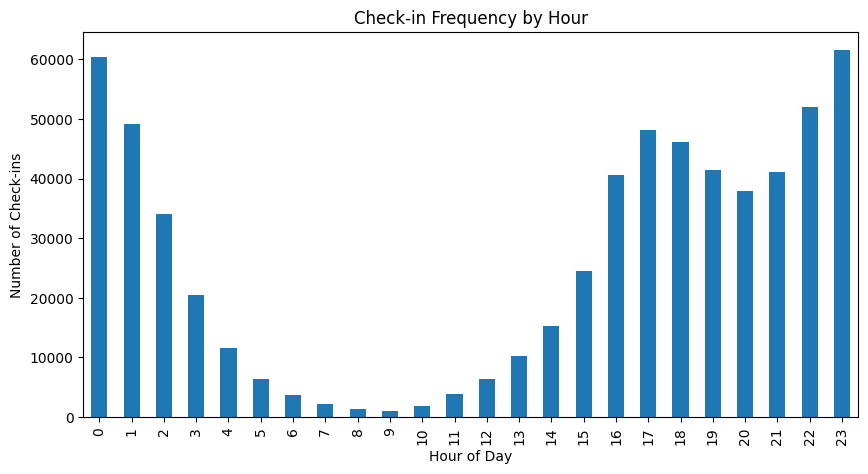

,0
hour,
23,61527
0,60409
22,52079
1,49226
17,48168
18,46080
19,41490
21,41110
16,40523


In [ ]:
hourly_counts = df_checkins_expanded.groupby('hour').size()

hourly_counts.plot(kind='bar', figsize=(10,5))
plt.title("Check-in Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Check-ins")
plt.show()

#peak hours
peak_hours = hourly_counts.sort_values(ascending=False).head(10)
peak_hours

In [ ]:
print("feature engineering")

def engineer_features(df_checkins, df_business, df_reviews):
    # ensure date column is datetime
    df_checkins['date'] = pd.to_datetime(df_checkins['date'])

    # aggregate check-ins by day
    daily_checkins = df_checkins.groupby(['business_id', 'date']).size().reset_index(name='checkin_count')

    # add time-based features
    daily_checkins['day_of_week'] = daily_checkins['date'].dt.dayofweek
    daily_checkins['month'] = daily_checkins['date'].dt.month
    daily_checkins['day_of_month'] = daily_checkins['date'].dt.day
    daily_checkins['week_of_year'] = daily_checkins['date'].dt.isocalendar().week
    daily_checkins['is_weekend'] = (daily_checkins['day_of_week'] >= 5).astype(int)

    # add lagged features
    daily_checkins = daily_checkins.sort_values(['business_id', 'date'])
    daily_checkins['lag_1'] = daily_checkins.groupby('business_id')['checkin_count'].shift(1)
    daily_checkins['lag_7'] = daily_checkins.groupby('business_id')['checkin_count'].shift(7)
    daily_checkins['rolling_mean_7'] = daily_checkins.groupby('business_id')['checkin_count'].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )

    # merge business features
    daily_checkins = daily_checkins.merge(
        df_business[['business_id', 'stars', 'review_count', 'categories']],
        on='business_id',
        how='left'
    )

    # calculate monthly average rating

    if 'date' in df_reviews.columns:
        df_reviews = df_reviews.copy()
        df_reviews['date'] = pd.to_datetime(df_reviews['date'])
        df_reviews['review_month'] = df_reviews['date'].dt.to_period('M')

        #calculate average rating per month
        monthly_sentiment = df_reviews.groupby(['business_id', 'review_month'])['stars'].mean().reset_index()
        monthly_sentiment.columns = ['business_id', 'month', 'avg_rating']


        monthly_review_counts = df_reviews.groupby(['business_id', 'review_month']).size().reset_index(name='monthly_review_count')


        monthly_sentiment = monthly_sentiment.merge(
            monthly_review_counts,
            left_on=['business_id', 'month'],
            right_on=['business_id', 'review_month'],
            how='left'
        )


        monthly_sentiment = monthly_sentiment.drop(columns=['review_month'])
    else:
        #if no reviews date, create empty dataframe
        monthly_sentiment = pd.DataFrame(columns=['business_id', 'month', 'avg_rating', 'monthly_review_count'])

    return daily_checkins, monthly_sentiment


df_reviews['date'] = pd.to_datetime(df_reviews['date'])

#run feature engineering
daily_checkins, monthly_sentiment = engineer_features(df_checkins_expanded, df_business, df_reviews)

print(f"daily checkins with features: {daily_checkins.shape}")
print(f"feature columns: {daily_checkins.columns.tolist()}")

feature engineering
daily checkins with features: (485945, 14)
feature columns: ['business_id', 'date', 'checkin_count', 'day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7', 'stars', 'review_count', 'categories']


In [ ]:
# tieme series
print("time series forecasting - traffic prediction (customers)")


# sample business
sample_business_id = daily_checkins['business_id'].value_counts().index[0]
business_data = daily_checkins[daily_checkins['business_id'] == sample_business_id].copy()
business_data = business_data.sort_values('date').reset_index(drop=True)

print(f"selected business: {sample_business_id}")
print(f"data points: {len(business_data)}")


train_size = int(len(business_data) * 0.8)
train_data = business_data[:train_size]
test_data = business_data[train_size:]

print(f"train size: {len(train_data)}, test size: {len(test_data)}")

time series forecasting - traffic prediction (customers)
selected business: 6Ty-KKWq6hLZYW8DWEHYvg
data points: 3167
train size: 2533, test size: 634


In [ ]:
# model 1 - prophet

prophet_train = train_data[['date', 'checkin_count']].rename(
    columns={'date': 'ds', 'checkin_count': 'y'}
)

#initialize and train Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

#make seasonalities
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

prophet_model.fit(prophet_train)


future = prophet_model.make_future_dataframe(periods=len(test_data))
prophet_forecast = prophet_model.predict(future)


prophet_test_pred = prophet_forecast.iloc[train_size:]['yhat'].values


prophet_mae = mean_absolute_error(test_data['checkin_count'], prophet_test_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_data['checkin_count'], prophet_test_pred))

print(f"prophet model - MAE: {prophet_mae:.2f}, RMSE: {prophet_rmse:.2f}")

# model 2 - XGBoost Model


# features XGBoost
feature_cols = ['day_of_week', 'month', 'day_of_month', 'week_of_year',
                'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7', 'stars', 'review_count']


train_data_xgb = train_data.dropna()
test_data_xgb = test_data.dropna()

X_train = train_data_xgb[feature_cols]
y_train = train_data_xgb['checkin_count']
X_test = test_data_xgb[feature_cols]
y_test = test_data_xgb['checkin_count']

#train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    random_state=42
)

xgb_model.fit(X_train, y_train)


xgb_pred = xgb_model.predict(X_test)


xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"XGBoost model - MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")

# model 3- ensemble model

#align predictions (we can use XGBoost test indices)
prophet_aligned = prophet_test_pred[test_data_xgb.index - train_size]

ensemble_pred = 0.4 * prophet_aligned + 0.6 * xgb_pred

#calc
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))

print(f"ensemble model - MAE: {ensemble_mae:.2f}, RMSE: {ensemble_rmse:.2f}")


prophet model - MAE: 1.33, RMSE: 1.77
XGBoost model - MAE: 1.17, RMSE: 1.39
ensemble model - MAE: 1.12, RMSE: 1.41



 time series visualizations


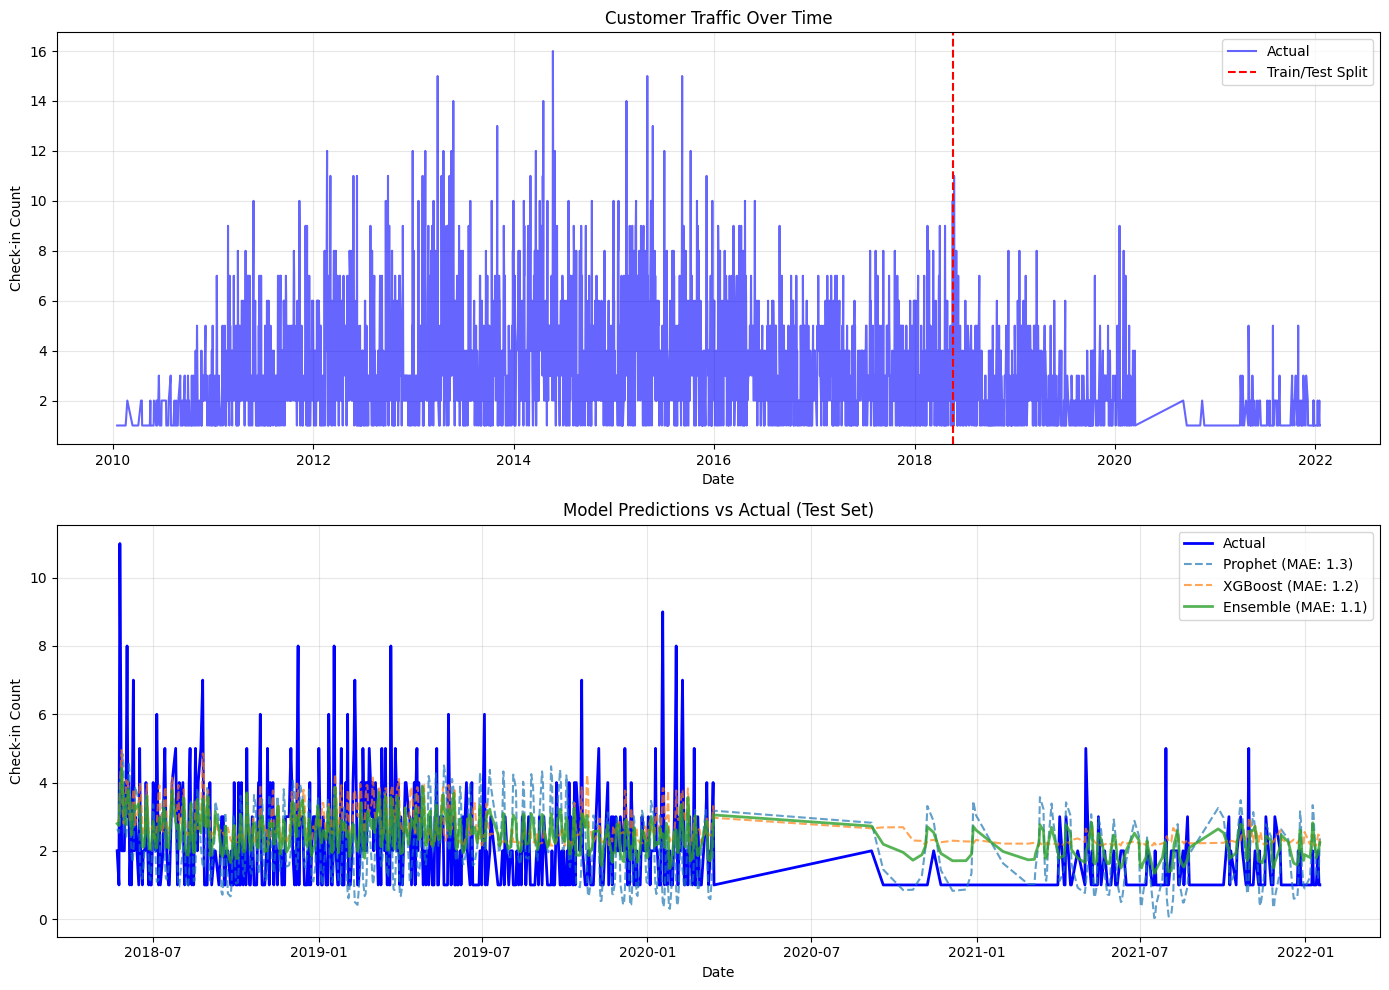

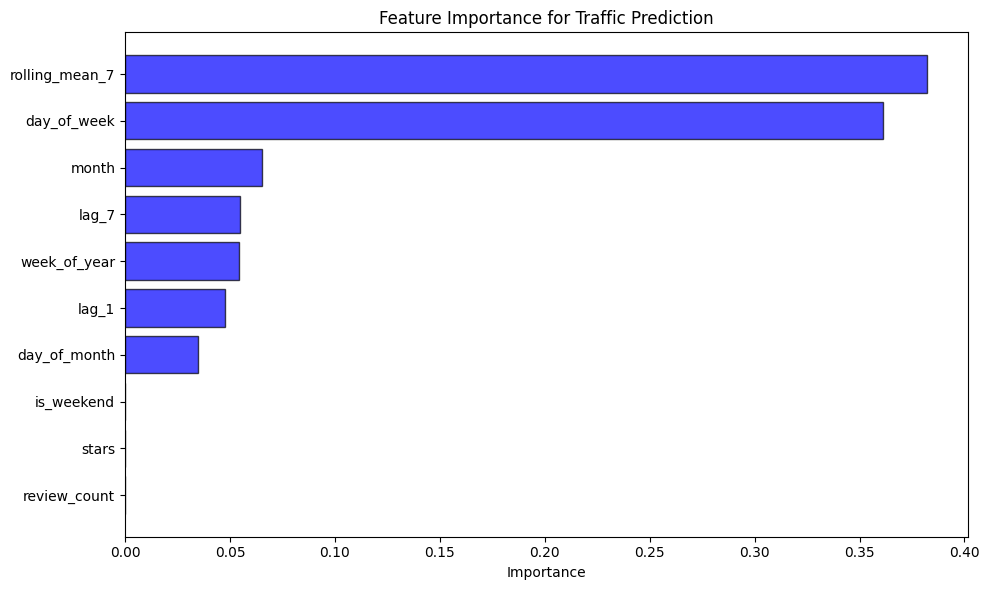

In [ ]:
print("\n time series visualizations")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#plot 1: full time series with train/test split
axes[0].plot(business_data['date'], business_data['checkin_count'],
             label='Actual', color='blue', alpha=0.6)
axes[0].axvline(x=train_data['date'].iloc[-1], color='red',
                linestyle='--', label='Train/Test Split')
axes[0].set_title('Customer Traffic Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Check-in Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#plot 2: test set predictions comparison
test_dates = test_data_xgb['date'].values

axes[1].plot(test_dates, y_test, label='Actual', color='blue', linewidth=2)
axes[1].plot(test_dates, prophet_aligned, label=f'Prophet (MAE: {prophet_mae:.1f})',
             alpha=0.7, linestyle='--')
axes[1].plot(test_dates, xgb_pred, label=f'XGBoost (MAE: {xgb_mae:.1f})',
             alpha=0.7, linestyle='--')
axes[1].plot(test_dates, ensemble_pred, label=f'Ensemble (MAE: {ensemble_mae:.1f})',
             alpha=0.8, linewidth=2)

axes[1].set_title('Model Predictions vs Actual (Test Set)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Check-in Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#from XGBoost
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance for Traffic Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:

print("nlp analysis - identifying 5 star drivers")

#sample 10,000 reviews
df_reviews_sample = df_reviews.sample(n=10000, random_state=42).copy()


df_reviews_sample['is_5_star'] = (df_reviews_sample['stars'] == 5).astype(int)
print(f"5-star reviews: {df_reviews_sample['is_5_star'].sum()} "
      f"({df_reviews_sample['is_5_star'].mean()*100:.1f}%)")

# text preprocessing (lowercase + remove non-letters, no lemmatization)
import re

def preprocess_text_fast(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

df_reviews_sample['clean_text'] = df_reviews_sample['text'].apply(preprocess_text_fast)

print("\n extracting review aspects")


aspect_keywords = {
    'service': ['service', 'staff', 'waiter', 'waitress', 'server', 'employee', 'manager',
                'friendly', 'rude', 'helpful', 'attentive', 'wait', 'waiting', 'waited', 'servers'],
    'food': ['food', 'meal', 'dish', 'taste', 'flavor', 'fresh', 'delicious', 'bland',
             'cold', 'hot', 'spicy', 'sweet', 'salty'],
    'ambiance': ['atmosphere', 'ambiance', 'decor', 'music', 'noise', 'quiet', 'loud',
                 'cozy', 'romantic', 'modern', 'clean', 'dirty'],
    'value': ['price', 'prices', 'expensive', 'cheap', 'affordable', 'value', 'worth',
              'overpriced', 'reasonable', 'cost', 'money', 'pricey', 'worth it', 'deal'],
    'speed': ['fast', 'slow', 'quick', 'wait', 'time', 'prompt', 'efficient', 'delay',
              'waiting', 'waited', 'quickly']
}

def extract_aspects(text):
    """aspects in review"""
    aspects = []
    for aspect, keywords in aspect_keywords.items():
        pattern = r'\b(?:' + '|'.join(keywords) + r')\b'
        if re.search(pattern, text):
            aspects.append(aspect)
    return aspects

df_reviews_sample['aspects'] = df_reviews_sample['clean_text'].apply(extract_aspects)

#count by rating
aspect_ratings = {}
for aspect in aspect_keywords.keys():
    aspect_reviews = df_reviews_sample[df_reviews_sample['aspects'].apply(lambda x: aspect in x)]
    aspect_ratings[aspect] = {
        'total_mentions': len(aspect_reviews),
        'avg_rating': aspect_reviews['stars'].mean(),
        '5_star_rate': (aspect_reviews['stars'] == 5).mean()
    }

aspect_df = pd.DataFrame(aspect_ratings).T
aspect_df = aspect_df.sort_values('5_star_rate', ascending=False)

print("\n aspect analysis results:")
print(aspect_df)


nlp analysis - identifying 5 star drivers
5-star reviews: 4529 (45.3%)

 extracting review aspects

 aspect analysis results:
          total_mentions  avg_rating  5_star_rate
food              6980.0    3.883811     0.454155
ambiance          2043.0    3.983847     0.452276
service           5761.0    3.775907     0.440375
speed             3924.0    3.714067     0.409021
value             2471.0    3.671388     0.374342


In [ ]:
print("\n review classification model")

X_train_text, X_test_text, y_train_nlp, y_test_nlp = train_test_split(
    df_reviews_sample['clean_text'],
    df_reviews_sample['is_5_star'],
    test_size=0.2,
    random_state=42,
    stratify=df_reviews_sample['is_5_star']
)


tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)


rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_classifier.fit(X_train_tfidf, y_train_nlp)


y_pred_nlp = rf_classifier.predict(X_test_tfidf)

accuracy = accuracy_score(y_test_nlp, y_pred_nlp)
print(f"\n classification accuracy: {accuracy*100:.1f}%")


print("\nclassification report:")
print(classification_report(y_test_nlp, y_pred_nlp, target_names=['Non-5-Star', '5-Star']))



 review classification model

 classification accuracy: 75.5%

classification report:
              precision    recall  f1-score   support

  Non-5-Star       0.74      0.85      0.79      1094
      5-Star       0.78      0.64      0.70       906

    accuracy                           0.76      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.76      0.76      0.75      2000




 nlp visualizations


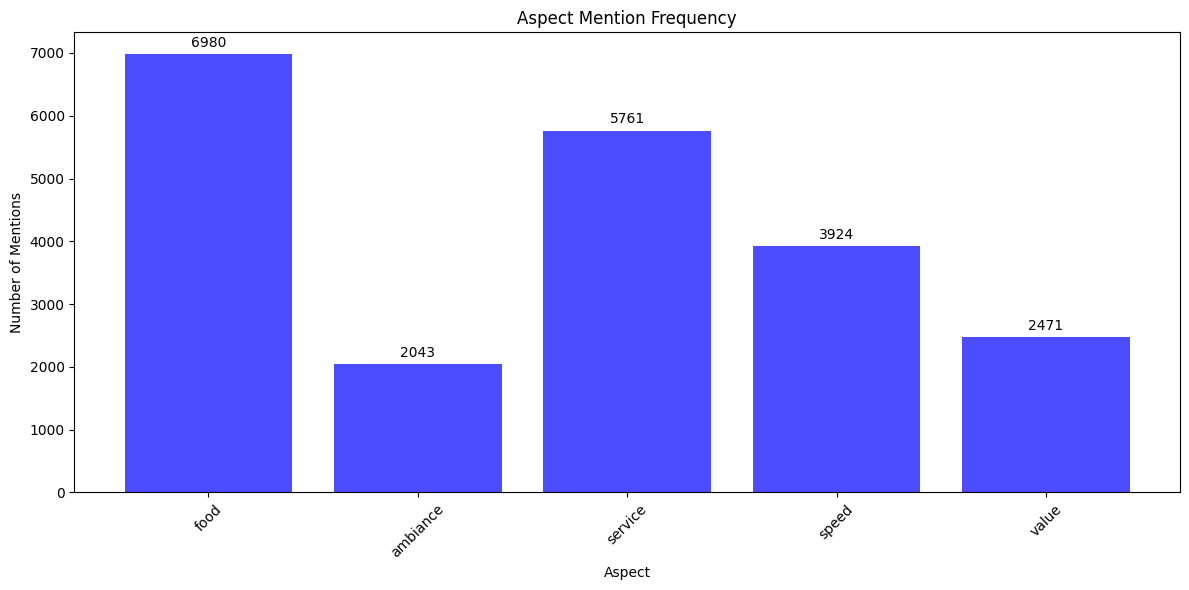

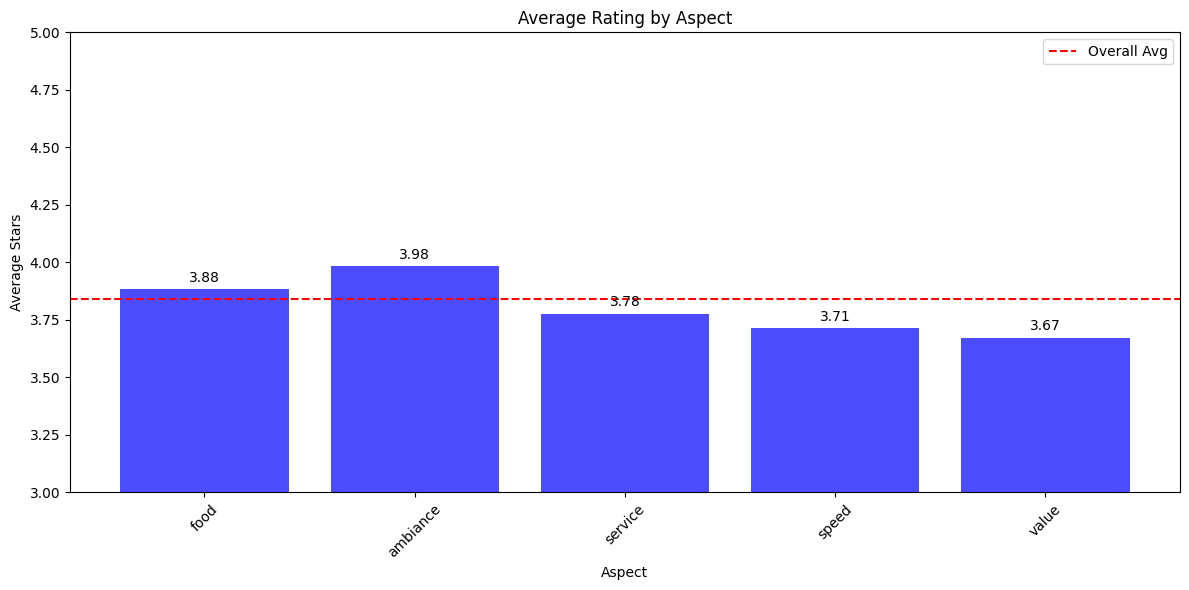

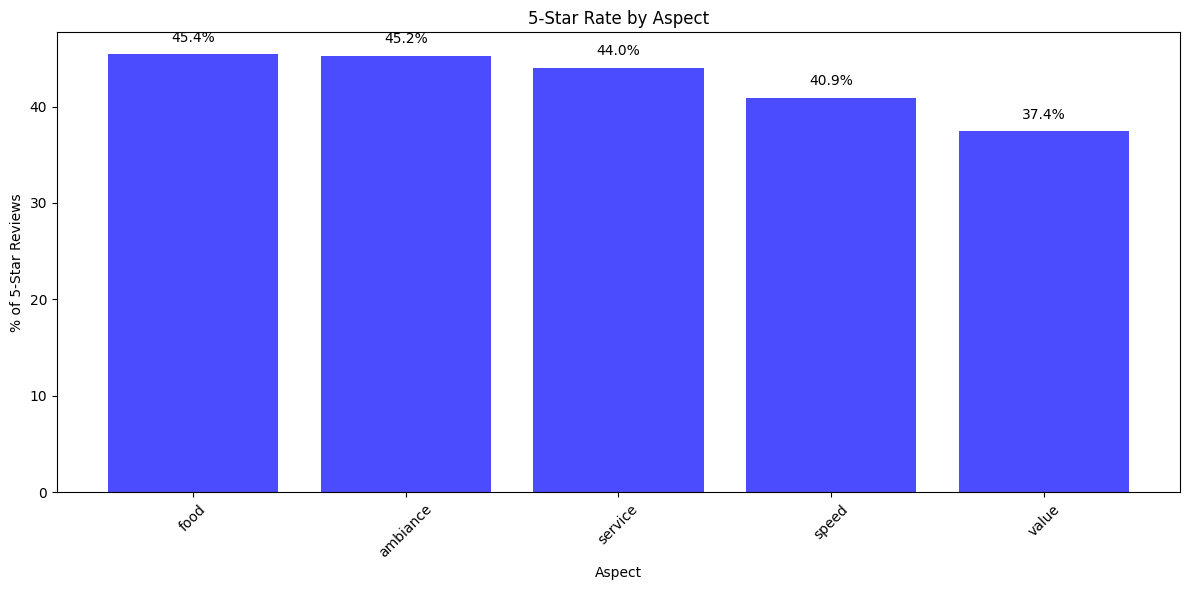

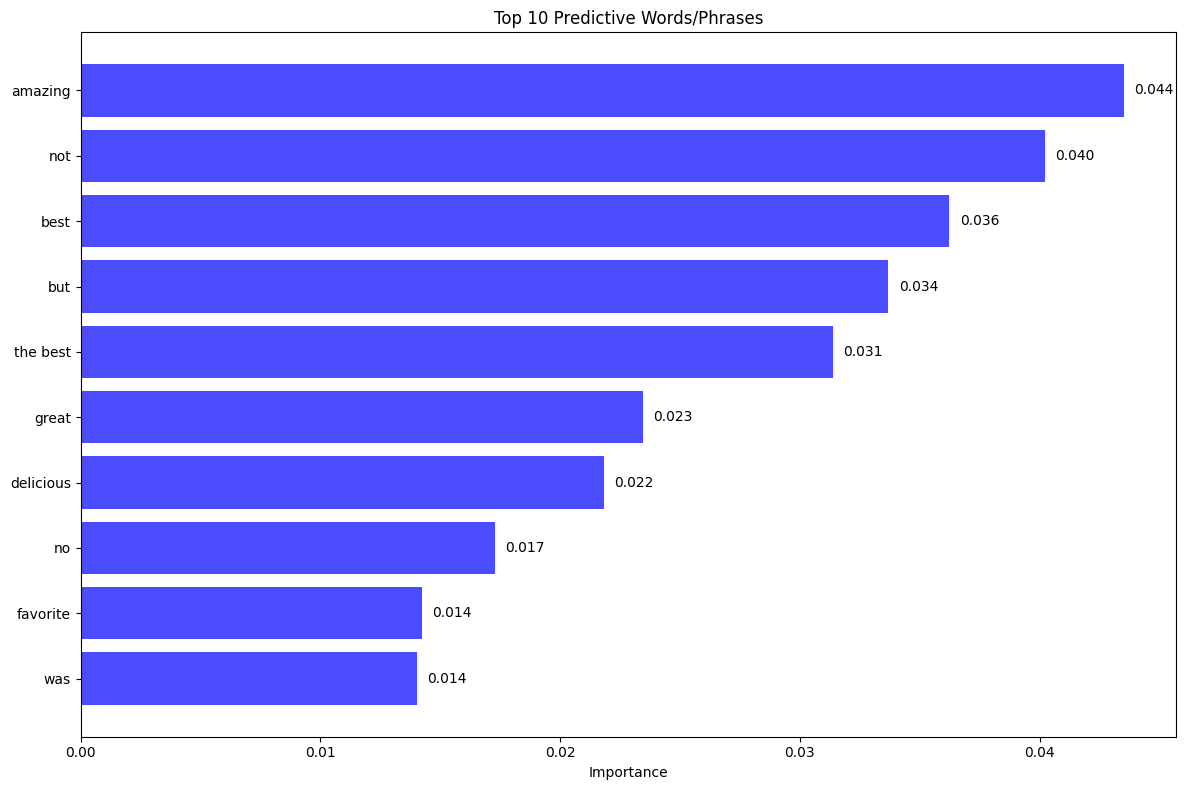

In [ ]:
print("\n nlp visualizations")

#aspect mention frequency
plt.figure(figsize=(12, 6))
bars1 = plt.bar(aspect_df.index, aspect_df['total_mentions'], color='blue', alpha=0.7)
plt.title('Aspect Mention Frequency')
plt.xlabel('Aspect')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)

# maybe we need to add the numbers
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + max(aspect_df['total_mentions'])*0.01,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#average rating
plt.figure(figsize=(12, 6))
bars2 = plt.bar(aspect_df.index, aspect_df['avg_rating'], color='blue', alpha=0.7)
plt.axhline(y=df_reviews_sample['stars'].mean(), color='red', linestyle='--', label='Overall Avg')
plt.title('Average Rating by Aspect')
plt.xlabel('Aspect')
plt.ylabel('Average Stars')
plt.ylim([3, 5])
plt.xticks(rotation=45)
plt.legend()


for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 5 star Rate
plt.figure(figsize=(12, 6))
bars3 = plt.bar(aspect_df.index, aspect_df['5_star_rate'] * 100, color='blue', alpha=0.7)
plt.title('5-Star Rate by Aspect')
plt.xlabel('Aspect')
plt.ylabel('% of 5-Star Reviews')
plt.xticks(rotation=45)


for bar in bars3:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#10 Predictive Words/Phrases
plt.figure(figsize=(12, 8))
bars4 = plt.barh(important_features['feature'][:10], important_features['importance'][:10],
                 color='blue', alpha=0.7)
plt.xlabel('Importance')
plt.title('Top 10 Predictive Words/Phrases')
plt.gca().invert_yaxis()


for bar in bars4:
    width = bar.get_width()
    plt.text(width + max(important_features['importance'][:10])*0.01,
             bar.get_y() + bar.get_height()/2.,
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:

# traffic forecast plot data
test_dates = test_data_xgb['date'].values

#importance
important_features = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_nlp
}).sort_values('importance', ascending=False).head(20)


aspect_metrics = aspect_df[['total_mentions', 'avg_rating', '5_star_rate']]


fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Traffic Forecast', 'Feature Importance',
                    'Review Aspects Impact', 'Model Comparison'),
    specs=[[{'type': 'scatter'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

#traffic forecast
fig.add_trace(
    go.Scatter(x=test_dates, y=y_test, name='Actual', line=dict(color='black')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=test_dates, y=ensemble_pred, name='Predicted',
               line=dict(color='skyblue', dash='dash')),
    row=1, col=1
)

#feature importance
fig.add_trace(
    go.Bar(x=important_features['importance'][:10][::-1],
           y=important_features['feature'][:10][::-1],
           orientation='h', marker_color='steelblue'),
    row=1, col=2
)


fig.add_trace(
    go.Bar(x=aspect_metrics.index, y=aspect_metrics['5_star_rate']*100,
           marker_color='cornflowerblue'),
    row=2, col=1
)

##comapre
models = ['Prophet', 'XGBoost', 'Ensemble']
mae_scores = [prophet_mae, xgb_mae, ensemble_mae]
fig.add_trace(
    go.Bar(x=models, y=mae_scores, marker_color=['dodgerblue', 'mediumblue', 'royalblue']),
    row=2, col=2
)


fig.update_layout(
    height=800,
    showlegend=True,
    title_text="Yelp Business Analytics",
    title_x=0.5
)


fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_yaxes(title_text="Check-ins", row=1, col=1)
fig.update_xaxes(title_text="Importance", row=1, col=2)
fig.update_yaxes(title_text="Feature", row=1, col=2)
fig.update_xaxes(title_text="Aspect", row=2, col=1)
fig.update_yaxes(title_text="5-Star Rate (%)", row=2, col=1)
fig.update_xaxes(title_text="Model", row=2, col=2)
fig.update_yaxes(title_text="MAE", row=2, col=2)

fig.show()
